In [ ]:
!pip install sympy==1.11
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 100.1 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.11.0+cu128 requires sympy>=1.13.3, but you have sympy 1.11 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 153.9 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.11
    Uninstalling sympy-1.11:
      Successfully uninstalled sympy-1.11


In [ ]:

from google.colab import drive
import os, random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms.functional as TF

# loading in data
drive.mount('/content/drive')

project_path     = "/content/drive/MyDrive/BEng_Project"
experiments_path = f"{project_path}/experiments"
os.makedirs(experiments_path, exist_ok=True)

backwards = np.load('/content/drive/MyDrive/Colab Notebooks/backwards_small.npy')
forwards  = np.load('/content/drive/MyDrive/Colab Notebooks/forwards_small.npy')
print(backwards.shape, forwards.shape)

# Used for augmenting data during training

class AugmentedDataset(Dataset):
    def __init__(self, images, masks, augment=True):
        self.images  = images
        self.masks   = masks
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img  = self.images[idx]
        mask = self.masks[idx]

        if self.augment:
            if random.random() > 0.1:
                img  = TF.hflip(img)
                mask = TF.hflip(mask)
            if random.random() > 0.1:
                img  = TF.vflip(img)
                mask = TF.vflip(mask)
            k = random.randint(0, 2)
            if k > 0:
                img  = torch.rot90(img,  k, dims=[1, 2])
                mask = torch.rot90(mask, k, dims=[1, 2])

        return img, mask

Mounted at /content/drive
(4960, 256, 256) (4960, 256, 256)


In [ ]:
# ############# DESIGNING Unet #############

import torch
import torch.nn as nn
import torch.nn.functional as F # Changed TF to F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False), # responsible for feature extraction. The bias is false as its cancelled by the instanc norm
            nn.InstanceNorm2d(out_channels), #InstanceNorm2d normalizes each image independently, making training stable for small bactch sizes
            nn.ReLU(inplace=True), # Introduces nonlinearity, which allows the model to learn complex relationships with out it the model would just be a linear model
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNET(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512, 1024]):
        super(UNET, self).__init__()
        self.ups = nn.ModuleList() #stores convolution layers
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.decoder_dropouts = nn.ModuleList([nn.Dropout2d(0.3) for _ in features ])
        self.bottleneck_dropout = nn.Dropout2d(0.3)

        # Downsampling path
        current_channels = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_channels, feature))
            current_channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Upsampling path
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2) # feature*2 as we are concatenating our feature through the skip conncetions
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        # Final output layer
        #self.final_conv = nn.Sequential(
            #nn.Conv2d(features[0], out_channels, kernel_size=1),
            #nn.Sigmoid()
        #)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)


    def forward(self, x):
        skip_connections = []

        # Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)
        x = self.bottleneck_dropout(x) # dropout
        skip_connections = skip_connections[::-1] # the list is reversed to make it easier

        # Decoder
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            x = self.decoder_dropouts[idx // 2](x) # dropout
            skip_connection = skip_connections[idx // 2]

            # Fix shape mismatch if needed
            if x.shape[2:] != skip_connection.shape[2:]:
                x = F.interpolate(x,size=skip_connection.shape[2:],mode="bilinear",align_corners=False) # Changed TF.interpolate to F.interpolate
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](concat_skip)

        return self.final_conv(x)

In [ ]:
import torch #  torch operations for tensors
from skimage import exposure
from scipy.spatial import cKDTree

# ── Metrics ────────────────────────────
def compute_iou(pred, target, threshold=0.2):
    pred_bin = (pred > threshold).float()
    p = pred_bin.detach().cpu().numpy().flatten()
    t = target.detach().cpu().numpy().flatten()
    intersection = np.sum(p * t)
    union = np.sum(p) + np.sum(t) - intersection
    return float(intersection / (union + 1e-7))

def compute_dice(pred, target, threshold=0.2):
    pred_bin = (pred > threshold).float()
    p = pred_bin.detach().cpu().numpy().flatten()
    t = target.detach().cpu().numpy().flatten()
    intersection = np.sum(p * t)
    return float((2 * intersection + 1e-7) / (np.sum(p) + np.sum(t) + 1e-7))

def hausdorff_95(y_true, y_pred):
    """
    Lower is better (distance in pixels).
    """
    # Move tensors to CPU and convert to numpy arrays
    y_true_np = y_true.cpu().numpy() # shape (B, 1, H, W)
    y_pred_np = y_pred.cpu().numpy() # shape (B, 1, H, W)

    batch_size = y_true_np.shape[0]
    metric_values = []

    for i in range(batch_size):
        single_y_true = y_true_np[i, 0, :, :] # shape (H, W)
        single_y_pred = y_pred_np[i, 0, :, :] # shape (H, W)

        # Threshold for finding the points
        u = np.argwhere(single_y_true > 0.5)
        v = np.argwhere(single_y_pred > 0.5)

        if len(u) == 0 or len(v) == 0:
            metric_values.append(100.0) # Error fallback
            continue

        # Calculate distance to closest points
        dist_uv, _ = cKDTree(v).query(u)
        dist_vu, _ = cKDTree(u).query(v)

        metric_values.append(max(np.percentile(dist_uv, 95), np.percentile(dist_vu, 95)))
    return np.mean(metric_values) if metric_values else 100.0

def Blockwise_diff(target, pred, block_size):

    # Automatically handle channel dimension if present (e.g., (B, 1, H, W))
    if target.dim() == 4 and target.shape[1] == 1:
        target = target.squeeze(1)
    if pred.dim() == 4 and pred.shape[1] == 1:
        pred = pred.squeeze(1)

    # Now both target and pred should be (B, H, W)
    # Dimension check for (B, H, W) format
    if target.dim() != 3 or pred.dim() != 3:
        raise ValueError("Input tensors must have 3 dimensions (B, H, W) after optional squeezing.")

    if target.shape != pred.shape:
        raise ValueError("Target and prediction images must have the same dimensions (B, H, W).")

    bh, bw = block_size

    num_images, H, W = target.shape # Use num_images, H, W for simplicity after check

    # Initialize a list to store all average block differences
    all_avg_diffs = []

    for i in range(num_images):
        for y in range(0, H, bh):
            for x in range(0, W, bw):
                pred_b = pred[i, y : min(y + bh, H), x : min(x + bw, W)] # Ensure bounds
                target_b = target[i, y : min(y + bh, H), x : min(x + bw, W)] # Ensure bounds

                # Calculate block difference and its average absolute value
                diff = pred_b - target_b
                avg_block_diff = torch.mean(torch.abs(diff))

                # Collect the average difference
                all_avg_diffs.append(avg_block_diff)

    # Return the overall average of all collected block differences
    if all_avg_diffs:
        return torch.mean(torch.stack(all_avg_diffs))
    else:
        return torch.tensor(0.0, device=target.device)



Run folder: /content/drive/MyDrive/BEng_Project/experiments/UNet_bs35_lr0.001_2026-07-08_11-12-54


/tmp/ipykernel_6668/566112872.py:97: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()



Epoch [1/150]


  0%|          | 0/115 [00:00<?, ?it/s]/tmp/ipykernel_6668/566112872.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


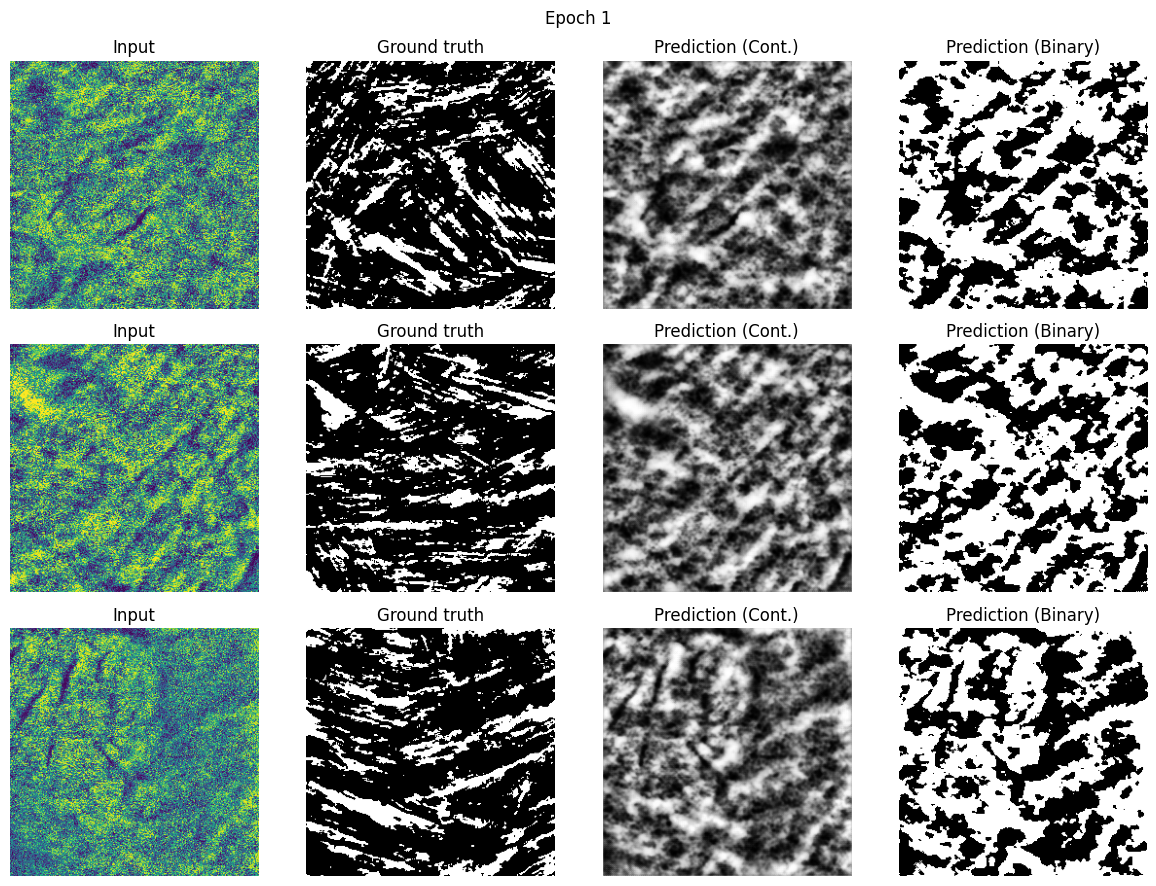

Train Loss: 0.5202 | Val Loss: 0.5010 | IoU: 0.3111 | DICE: 0.4745 | Hausdroff_95: 7.8617 |Blockwise_diff: 0.4213

Epoch [2/150]


Train Loss: 0.5023 | Val Loss: 0.4981 | IoU: 0.3129 | DICE: 0.4767 | Hausdroff_95: 7.7569 |Blockwise_diff: 0.4210

Epoch [3/150]


KeyboardInterrupt: 

In [ ]:
import torch.nn as nn
import torch.optim as optim
import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Train ──────────────────────────────────────────
def train_fn(loader, model, optimizer, loss_fn, scaler, device):
    model.train()
    epoch_loss = 0.0
    for data, targets in tqdm(loader, leave=False):
        data, targets = data.to(device), targets.to(device)
        with torch.cuda.amp.autocast():
            predictions = model(data)
            loss = loss_fn(predictions, targets)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)


# ── Validation ──────────────────────────
def val_fn(loader, model, loss_fn, epoch, device, run_path, block_size):
    model.eval()
    val_loss = val_iou = val_dice = val_hausdroff_95 = val_Blockwise_diff = 0.0

    with torch.no_grad():
        for idx, (data, targets) in enumerate(loader):
            data, targets = data.to(device), targets.to(device)
            predictions = model(data)

            val_loss += loss_fn(predictions, targets).item()

            preds_sig = torch.sigmoid(predictions)
            preds_binary = (preds_sig > 0.2).float() # Explicitly apply threshold for visualization

            # Metrics computed with binarized predictions (except SSIM)
            val_iou  += compute_iou(preds_binary, targets)
            val_dice += compute_dice(preds_binary, targets)
            val_hausdroff_95 += hausdorff_95(preds_binary, targets)
            val_Blockwise_diff += Blockwise_diff(targets, preds_binary, block_size).item()

            if idx == 0 and (epoch % 10 == 0):
                fig, axes = plt.subplots(3, 4, figsize=(12, 9)) # Increased columns for binary prediction
                for i in range(3):
                    axes[i,0].imshow(exposure.equalize_adapthist(data[i].squeeze(0).cpu().numpy(), clip_limit=0.018), cmap='viridis')
                    axes[i,0].set_title("Input"); axes[i,0].axis('off')
                    axes[i,1].imshow(exposure.equalize_adapthist(targets[i].squeeze(0).cpu().numpy(), clip_limit=0.01), cmap='gray')
                    axes[i,1].set_title("Ground truth"); axes[i,1].axis('off')
                    axes[i,2].imshow(exposure.equalize_adapthist(preds_sig[i].squeeze(0).cpu().numpy(), clip_limit=0.01), cmap='gray')
                    axes[i,2].set_title("Prediction (Cont.)"); axes[i,2].axis('off') # Label for continuous prediction
                    axes[i,3].imshow(preds_binary[i].squeeze(0).cpu().numpy(), cmap='gray') # Display binary prediction
                    axes[i,3].set_title("Prediction (Binary)"); axes[i,3].axis('off') # Label for binary prediction
                plt.suptitle(f"Epoch {epoch+1}")
                plt.tight_layout()
                plt.savefig(f"{run_path}/predictions_epoch{epoch+1}.png", bbox_inches='tight')
                plt.show(); plt.close()

    n = len(loader)
    return val_loss/n, val_iou/n, val_dice/n, val_hausdroff_95/n, val_Blockwise_diff/n


# ── Config ──────────────────────────────────────
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 0.001
num_epochs    = 150
batch_size    = 35
block_size    = (32, 32)

run_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_name = f"UNet_bs{batch_size}_lr{learning_rate}_{run_time}"
run_path = f"{experiments_path}/{run_name}"
os.makedirs(run_path, exist_ok=True)
print(f"Run folder: {run_path}")

# ── Data splits ──────────────────────────
backward_tensor = torch.from_numpy(backwards).unsqueeze(1).float()
forward_tensor  = torch.from_numpy(forwards).unsqueeze(1).float()

X_train, X_test, y_train, y_test = train_test_split(
    backward_tensor, forward_tensor, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42)

train_dataloader = DataLoader(AugmentedDataset(X_train, y_train, augment=True),  batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(torch.utils.data.TensorDataset(X_val,   y_val), batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(torch.utils.data.TensorDataset(X_test,  y_test), batch_size=batch_size, shuffle=False)

# ── Model ───────────────────────────────
model     = UNET(in_channels=1, out_channels=1).to(device)
loss_fn   = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scaler    = torch.cuda.amp.GradScaler()

train_losses = []
val_losses, val_ious, val_dices, val_hausdroff_95, val_Blockwise_diff = [], [], [], [], []

with open(f"{run_path}/run.txt", "w") as f:
    f.write(f"Model: {str(model)}\n\n")
    f.write(f"Learning rate: {learning_rate}\n")
    f.write(f"Batch size:    {batch_size}\n")
    f.write(f"Epochs:        {num_epochs}\n")
    f.write(f"Augmentation:  HFlip, VFlip, Rot90\n")
    f.write(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)}\n")

# ── Training loop ─────────────────────────
for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    train_loss = train_fn(train_dataloader, model, optimizer, loss_fn, scaler, device)
    val_loss, val_iou, val_dice, val_hausdroff_95_epoch, val_Blockwise_diff_epoch = val_fn(
        val_dataloader, model, loss_fn, epoch, device, run_path, block_size)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ious.append(val_iou)
    val_dices.append(val_dice)
    val_hausdroff_95.append(val_hausdroff_95_epoch)
    val_Blockwise_diff.append(val_Blockwise_diff_epoch)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"IoU: {val_iou:.4f} | DICE: {val_dice:.4f} | Hausdroff_95: {val_hausdroff_95_epoch:.4f} |Blockwise_diff: {val_Blockwise_diff_epoch:.4f}")

# ── Save model ───────────────────────────
torch.save(model.state_dict(), f"{run_path}/model.pth")
print(f"\nModel saved to {run_path}/model.pth")

# ── Plot metrics ───────────────────────────
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(3, 3, figsize=(15, 12)) # Changed to 3x3
fig.suptitle("Training summary")

axes[0,0].plot(epochs, train_losses, label="Train"); axes[0,0].plot(epochs, val_losses, label="Val")
axes[0,0].set_title("Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()

axes[0,1].plot(epochs, val_ious, color="tab:orange")
axes[0,1].set_title("Validation IoU"); axes[0,1].set_xlabel("Epoch")

axes[0,2].plot(epochs, val_dices, color="tab:green") # Moved to 0,2
axes[0,2].set_title("Validation DICE"); axes[0,2].set_xlabel("Epoch")

axes[1,1].plot(epochs, val_hausdroff_95, color="tab:blue") # Moved to 1,1
axes[1,1].set_title("Validation Hausdroff_95"); axes[1,1].set_xlabel("Epoch")

axes[2,1].plot(epochs, val_Blockwise_diff, color="tab:gray") # New plot at 2,1
axes[2,1].set_title("Validation Blockwise Diff"); axes[2,1].set_xlabel("Epoch")

axes[2,2].axis('off') # Turn off the last unused subplot

plt.tight_layout()
plt.savefig(f"{run_path}/all_metrics.png", dpi=150)
plt.show(); plt.close()

# Save metric arrays
for name, arr in [("train_losses", train_losses), ("val_losses", val_losses),
                  ("val_ious", val_ious), ("val_dices", val_dices),
                  ("val_hausdroff_95", val_hausdroff_95),
                  ("val_Blockwise_diff", val_Blockwise_diff)]:
    np.save(f"{run_path}/{name}.npy", np.array(arr))

with open(f"{run_path}/run.txt", "a") as f:
    f.write(f"\nTEST RESULTS:\n")
    f.write(f"  IoU:  {val_ious[-1]:.6f}\n")
    f.write(f"  DICE: {val_dices[-1]:.6f}\n")
    f.write(f"  Hausdroff_95: {val_hausdroff_95[-1]:.6f}\n")
    f.write(f"  Final val Blockwise_diff: {val_Blockwise_diff[-1]:.6f}\n")

    f.write(f"  Std Dev IoU: {np.std(val_ious):.6f}\n")
    f.write(f"  Std Dev DICE: {np.std(val_dices):.6f}\n")
    f.write(f"  Std Dev Hausdroff_95: {np.std(val_hausdroff_95):.6f}\n")
    f.write(f"  Std Dev val_Blockwise_diff: {np.std(val_Blockwise_diff):.6f}\n")

In [ ]:
import tifffile
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from scipy.spatial import cKDTree

# ── Point at a model ──────────────────────────────────────────────────
# Option A: use the model still in memory from Cell 3 (run immediately after)
# run_path is already set — just run the cell as-is


# Option B: loading a saved model later — uncomment and set the path also make sure to run the cell with the memtric definitation
#model_path = "/content/drive/MyDrive/BEng_Project/experiments/UNet_bs35_lr0.001_2026-04-13_12-04-10/model.pth"
#device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#run_path   = os.path.dirname(model_path)
#model      = UNET(in_channels=1, out_channels=1).to(device)
#model.load_state_dict(torch.load(model_path, map_location=device))

model.eval()
print(f"Saving test outputs to: {run_path}")

# ── Rebuild test split (same random_state ensures identical split) ─────
backward_tensor = torch.from_numpy(backwards).unsqueeze(1).float()
forward_tensor  = torch.from_numpy(forwards).unsqueeze(1).float()

_, X_test, _, y_test = train_test_split(
    backward_tensor, forward_tensor, test_size=0.1, random_state=42)

test_dataloader = DataLoader(
    torch.utils.data.TensorDataset(X_test, y_test),
    batch_size=35, shuffle=False)

# ── Collect predictions ───────────────────────────────────────────────
all_inputs, all_preds, all_preds_bi, all_targets = [], [], [], [] # Added all_preds_bi
iou_scores, dice_scores, hausdroff_95_score = [], [], []

# --- New: For Blockwise difference  ---
block_size = (32, 32) # Define your desired block size (e.g., 16x16 pixels)
all_Blockwise_diffs = []
# -------------------------------------

with torch.no_grad():
    for data, targets in test_dataloader:
        data, targets = data.to(device), targets.to(device)
        preds_sig = torch.sigmoid(model(data))
        preds_binary = (preds_sig > 0.2).float()

        iou_scores.append(compute_iou(preds_sig, targets))
        dice_scores.append(compute_dice(preds_sig, targets))
        hausdroff_95_score.append(hausdorff_95(preds_binary, targets))

        # --- Calculate Patch Entropy Difference ---
        avg_diff = Blockwise_diff(targets, preds_binary, block_size)
        all_Blockwise_diffs.append(avg_diff.item())
        # -------------------------------------------------

        all_inputs.append(data.cpu())
        all_preds.append(preds_sig.cpu())
        all_preds_bi.append(preds_binary.cpu())
        all_targets.append(targets.cpu())

all_inputs  = torch.cat(all_inputs,  dim=0)[:, 0].numpy().astype(np.float32)
all_preds   = torch.cat(all_preds,   dim=0)[:, 0].numpy().astype(np.float32)
all_preds_bi   = torch.cat(all_preds_bi,   dim=0)[:, 0].numpy().astype(np.float32)
all_targets = torch.cat(all_targets, dim=0)[:, 0].numpy().astype(np.float32)

# ── Save TIFFs into the run folder ────────────────────────────────────
tifffile.imwrite(f"{run_path}/test_inputs.tif",       all_inputs)
tifffile.imwrite(f"{run_path}/test_predictions.tif",  all_preds)
tifffile.imwrite(f"{run_path}/test_predictions_bi.tif",  all_preds_bi)
tifffile.imwrite(f"{run_path}/test_ground_truth.tif", all_targets)

test_iou  = float(np.mean(iou_scores))
test_dice = float(np.mean(dice_scores))
test_hausdroff_95 = float(np.mean(hausdroff_95_score))


# --- New: Overall Average Patch Entropy Difference ---
overall_avg_blockwise_diff = float(np.mean(all_Blockwise_diffs))
# ---------------------------------------------------

print(f"Saved {len(all_preds)} slices")
print(f"Test IoU:  {test_iou:.4f}")
print(f"Test DICE: {test_dice:.4f}")
print(f"Test Hausdroff_95: {test_hausdroff_95:.4f}")
print(f"Average Patch  Diff (block_size={block_size}): {overall_avg_blockwise_diff:.4f}")

# Calculate and print standard deviations for each metric
print(f"Std Dev IoU: {np.std(iou_scores):.4f}")
print(f"Std Dev DICE: {np.std(dice_scores):.4f}")
print(f"Std Dev Hausdroff_95: {np.std(hausdroff_95_score):.4f}")
print(f"Std Dev Average Patch Diff: {np.std(all_Blockwise_diffs):.4f}")

with open(f"{run_path}/run.txt", "a") as f:
    f.write(f"\nTEST RESULTS:\n")
    f.write(f"  IoU:  {test_iou:.6f}\n")
    f.write(f"  DICE: {test_dice:.6f}\n")
    f.write(f"  Hausdroff_95: {test_hausdroff_95:.6f}\n")
    f.write(f"  Average Patch  Diff (block_size={block_size}): {overall_avg_blockwise_diff:.6f}\n")

    f.write(f"  Std Dev IoU: {np.std(iou_scores):.6f}\n")
    f.write(f"  Std Dev DICE: {np.std(dice_scores):.6f}\n")
    f.write(f"  Std Dev Hausdroff_95: {np.std(hausdroff_95_score):.6f}\n")
    f.write(f"  Std Dev Average Patch Diff: {np.std(all_Blockwise_diffs):.6f}\n")

Saving test outputs to: /content/drive/MyDrive/BEng_Project/experiments/UNet_bs35_lr0.001_2026-04-26_20-31-35
Saved 496 slices
Test IoU:  0.4398
Test DICE: 0.6108
Test SSIM: 0.2534
Test Hausdroff_95: 5.3451
Test Tversky_index: 0.5598
Test Fiber_accuracy: 0.6165
Average Patch  Diff (block_size=(32, 32)): 0.2489
Std Dev IoU: 0.0095
Std Dev DICE: 0.0091
Std Dev SSIM: 0.0118
Std Dev Hausdroff_95: 0.8405
Std Dev Tversky_index: 0.0087
Std Dev Fiber_accuracy: 0.0114
Std Dev Average Patch Diff: 0.0090
